In [1]:
from m_star_predictor import (
    LinearRegression, FCNN, fit_model, predict_autoregressive
)

from utility import (
    normalize, real_units, reduce_dataset, compute_rmse, MStarAutoregressivePredictorConfig,
    get_autoregressive_predictions, recover_M_from_dM
)

import torch
import torch.utils.data as Data
from torch.utils.data import random_split
from torch import optim
import numpy as np
import os
import json

import pandas as pd

import matplotlib.pyplot as plt

In [2]:
predictor_name = "predictor_1"
predictor_dir = os.path.join("m_star_autoregressive_predictors", predictor_name)
config_json_path = os.path.join(predictor_dir, "config.json")

with open(config_json_path, "r") as f:
    config_dict = json.load(f)

config = MStarAutoregressivePredictorConfig(**config_dict)

In [3]:
# Ensuring reproducibility
np.random.seed(config.random_state)
torch.manual_seed(config.random_state);
sklear_random_state = config.random_state

In [4]:
fcnn_train_traj = config.train_loss_trajectory
fcnn_test_traj = config.test_loss_trajectory
fcnn_name = ""

Text(0.5, 0, 'Epoch')

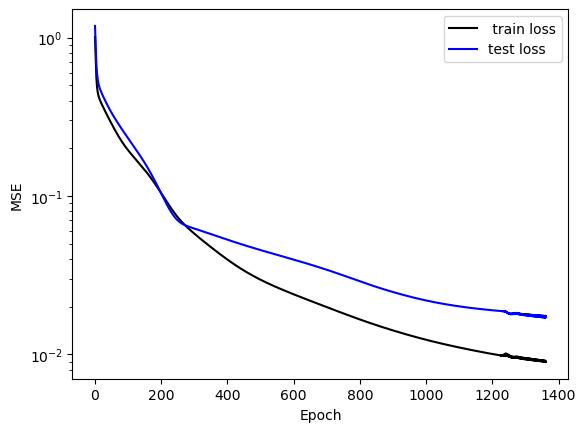

In [5]:
plt.plot(fcnn_train_traj, color="black", label=f" train loss")
plt.plot(fcnn_test_traj, color="blue", label=f"test loss")
plt.gca().set_yscale("log")
plt.legend()
plt.ylabel("MSE")
plt.xlabel("Epoch")

In [6]:
data_directory = '../m_star_dataset'

dataset_name = config.dataset_name
validation_dataset_name = config.validation_dataset_name

data = pd.read_csv(os.path.join(data_directory, f"{config.dataset_filename}.csv"))
validation_data = pd.read_csv(os.path.join(data_directory, f"{config.validation_dataset_filename}.csv"))

In [7]:
with open(os.path.join(data_directory, f'{dataset_name}_training_set_cases.json'), 'r') as file:
    gotm_case_dict = json.load(file)

with open(os.path.join(data_directory, f'{validation_dataset_name}_training_set_cases.json'), 'r') as file:
    gotm_validation_case_dict = json.load(file)

In [8]:
X, y, X_val, y_val, fcnn_prediction, fcnn_prediction_val = get_autoregressive_predictions(
    training_data=data,
    validation_data=validation_data,
    config=config
)

In [9]:
config.rmse

5.401054750109324e-07

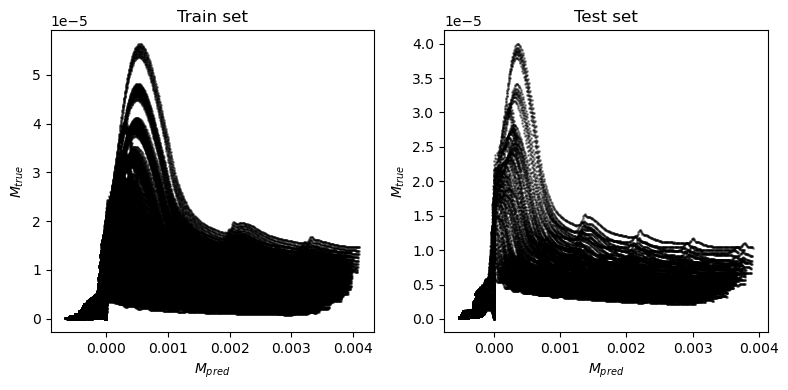

In [10]:
xs, ys = np.linspace(0., 6e-3, 1000), np.linspace(0., 6e-3, 1000)

fig, ax = plt.subplots(1,2,figsize=(8,4))
ax[0].scatter(fcnn_prediction.detach().numpy(), y, color="black", s=1, alpha=.4)
# ax[0].plot(xs, ys, color="red", linestyle="dashed")
ax[0].set_ylabel("$M_{true}$")
ax[0].set_xlabel("$M_{pred}$")
ax[0].set_title("Train set")

ax[1].scatter(fcnn_prediction_val.detach().numpy(), y_val, color="black", s=1, alpha=.4)
# ax[1].plot(xs, ys, color="red", linestyle="dashed")
ax[1].set_ylabel("$M_{true}$")
ax[1].set_xlabel("$M_{pred}$")
ax[1].set_title("Test set")

# fig.suptitle(f"Train and test predictions for {name_1}")

# for a in ax:
    # a.set_xscale("log")
    # a.set_yscale("log")
    # a.set_xlim(0, 1e-5)
    # a.set_ylim(0, 1e-5)

fig.tight_layout()

# plt.savefig(f"inst_M_true_pred_{name_1}.png", dpi=300)

In [ ]:
start, end = 0, 40
n_timesteps = 432

for i in range(start, end):
    case_specs = gotm_validation_case_dict[f"case_{i+1}"]
    tg, tx, lat, hf = case_specs['temp_grad'], case_specs['tx'], case_specs['lat'], case_specs['heat_flux']
    plt.figure(tight_layout=True, figsize=(10,3))
    plt.title(f"temp_grad: {tg}, tx: {tx}, lat: {lat}, hf: {hf}")
    plt.plot(fcnn_prediction_val.detach().numpy()[i], label="M$_{pred}$", color="red")
    plt.plot(y_val[i], label="M$_{true}$", color="black")
    plt.xlabel("Time step [30 min]")
    plt.ylabel("M")
    plt.legend()

/tmp/ipykernel_3789881/2174972767.py:7: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  plt.figure(tight_layout=True, figsize=(10,3))


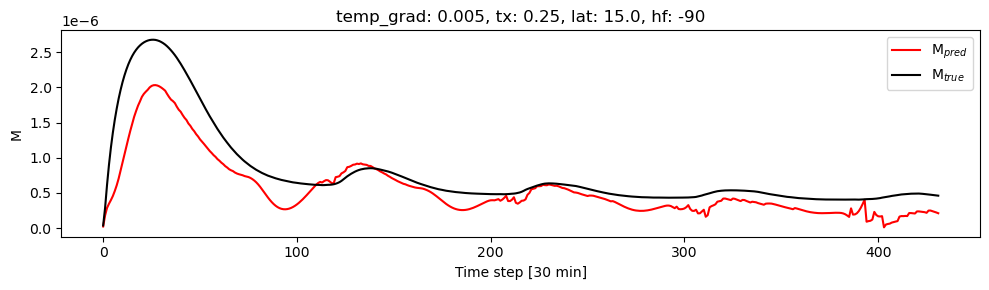

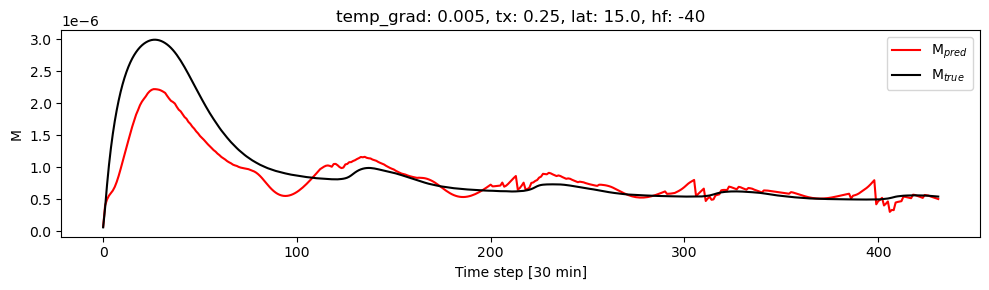

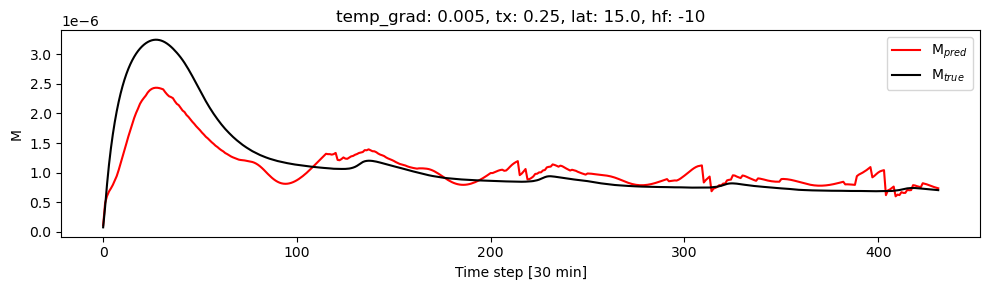

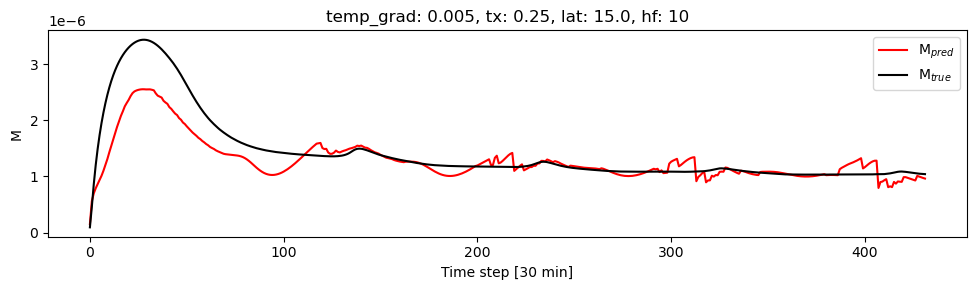

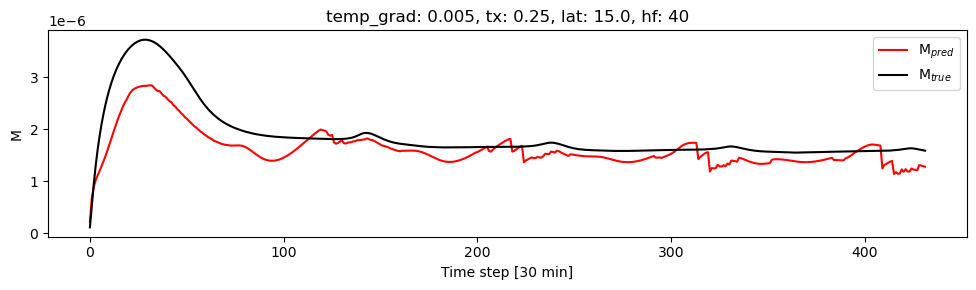

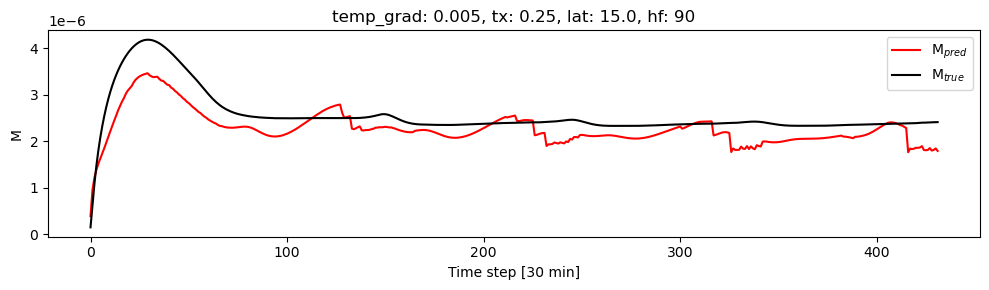

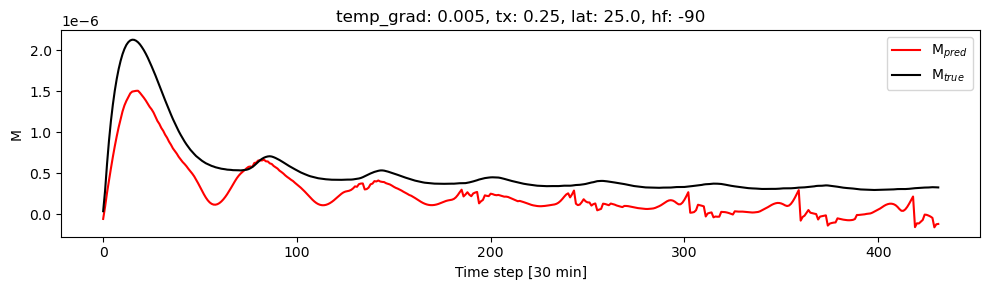

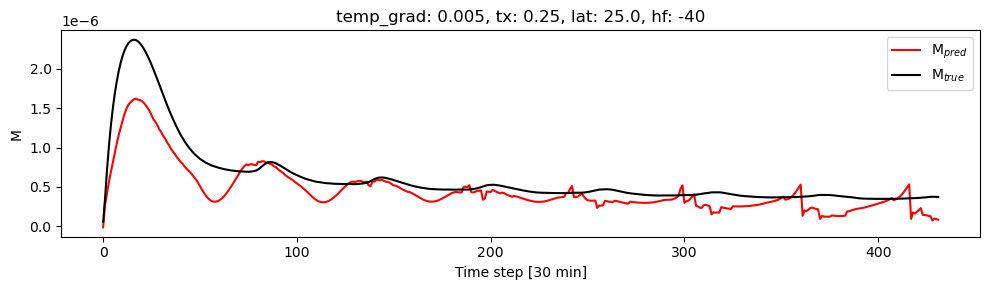

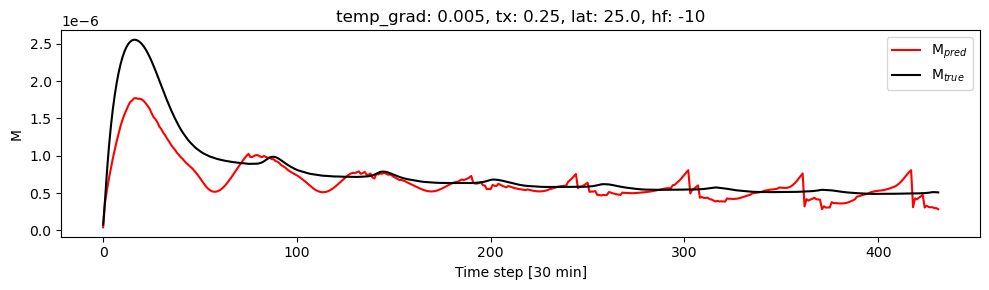

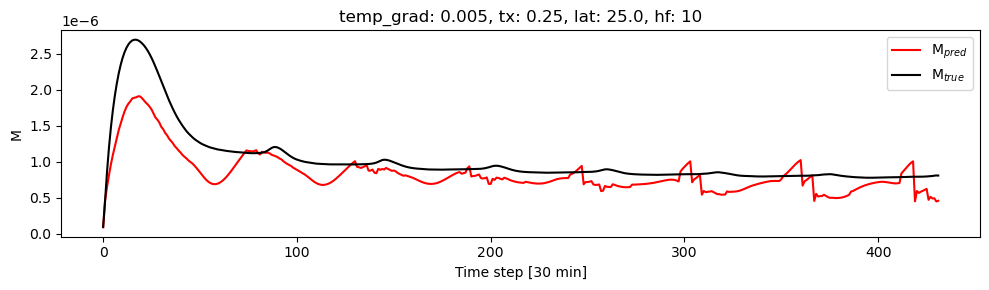

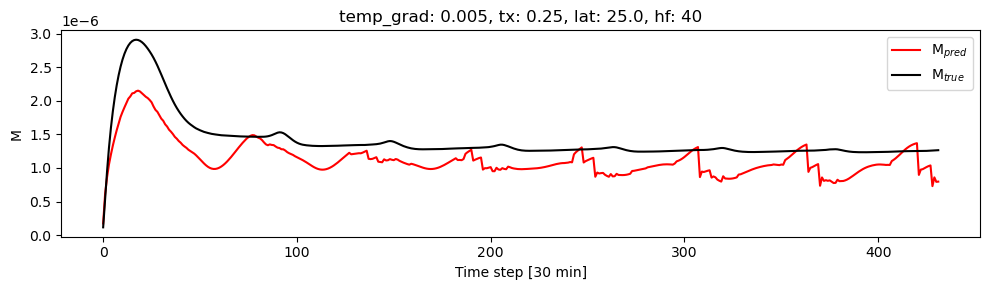

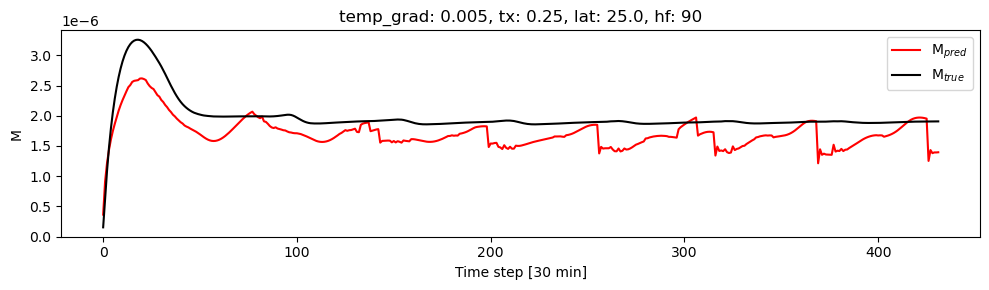

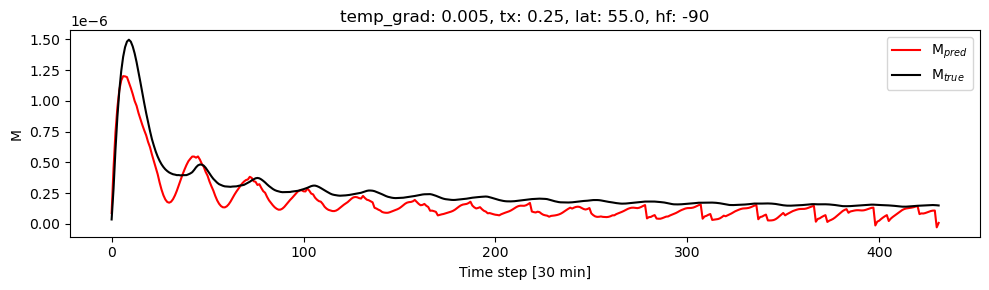

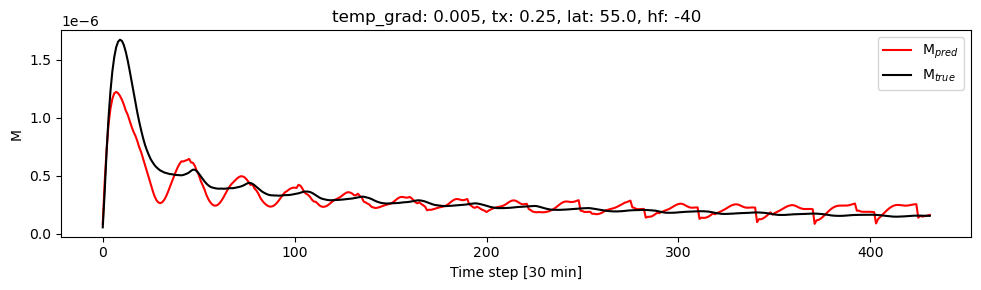

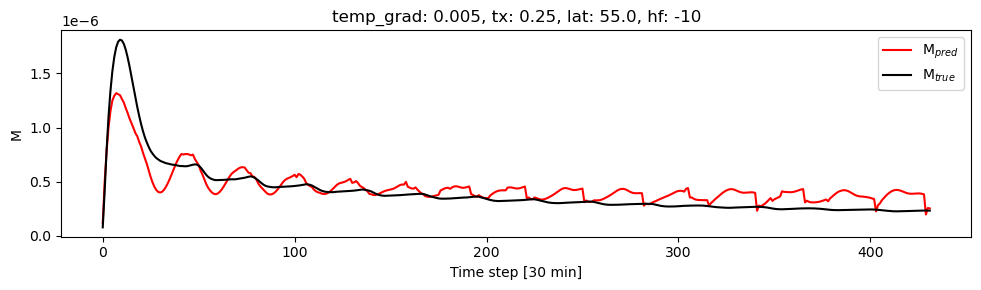

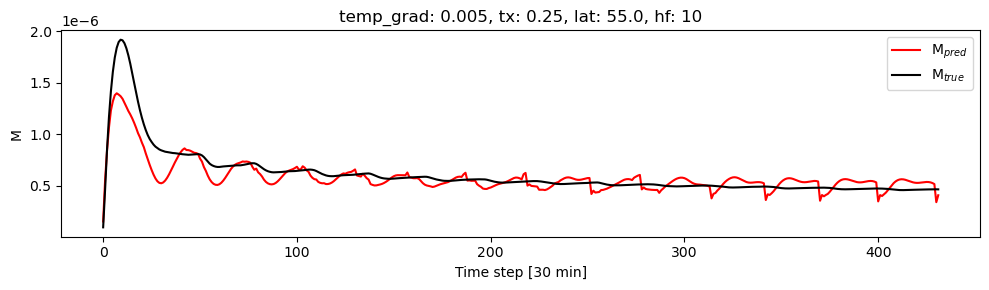

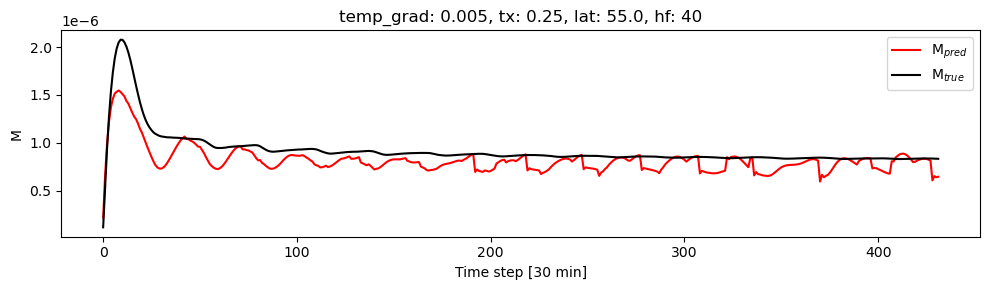

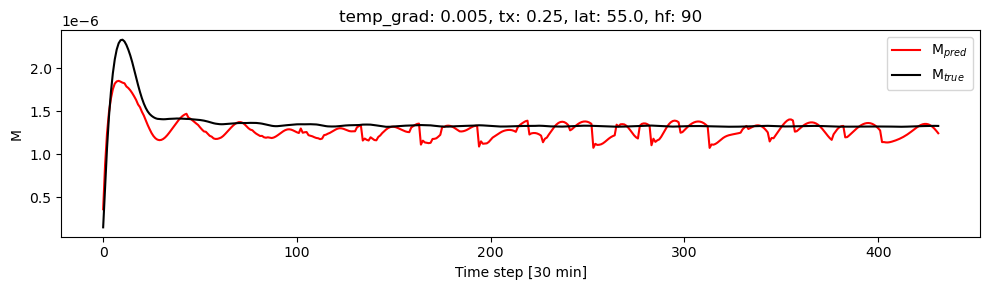

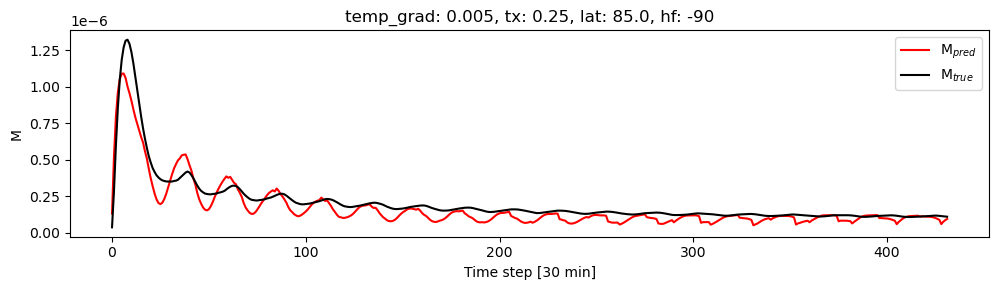

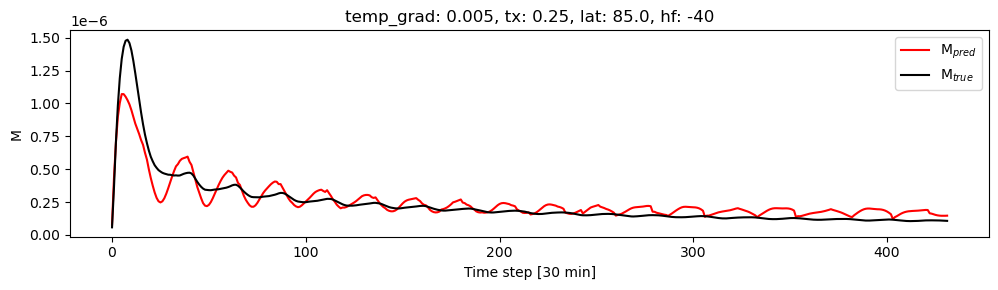

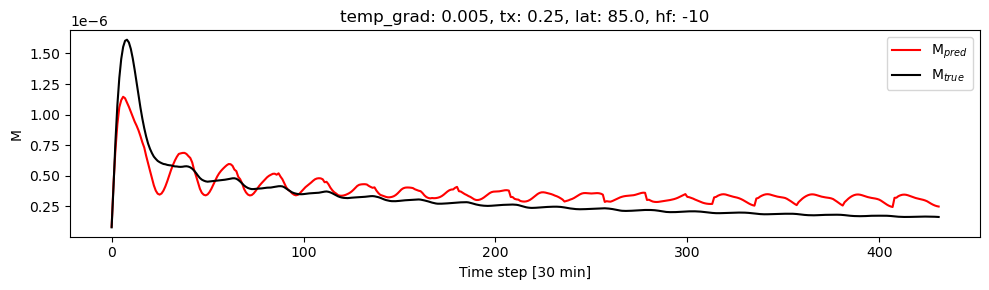

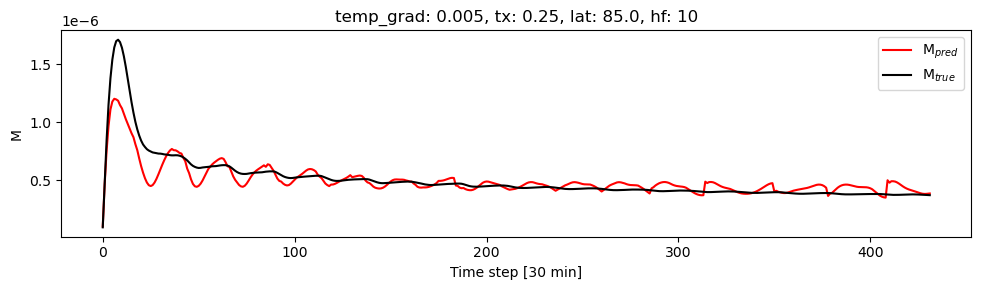

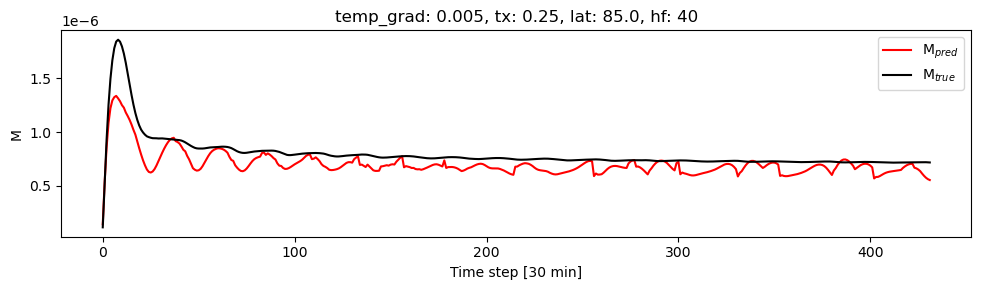

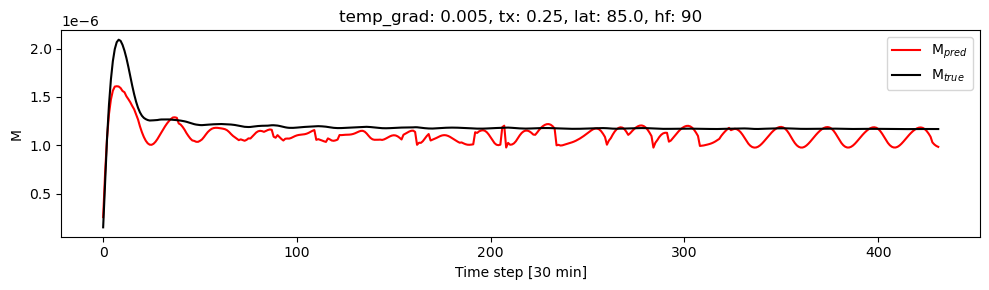

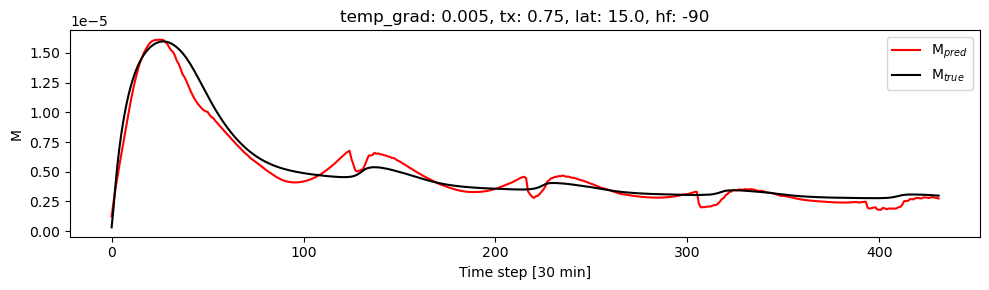

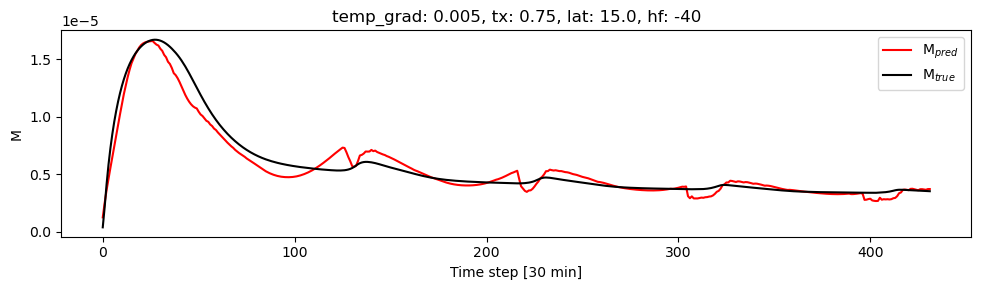

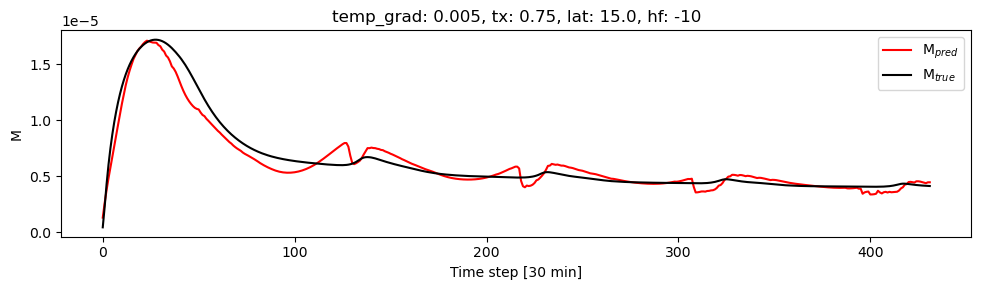

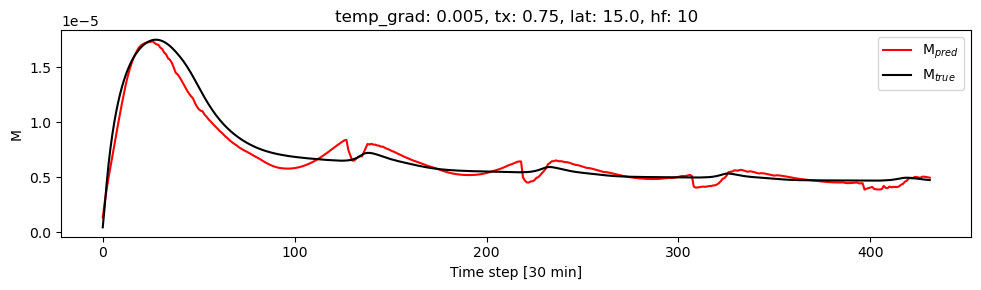

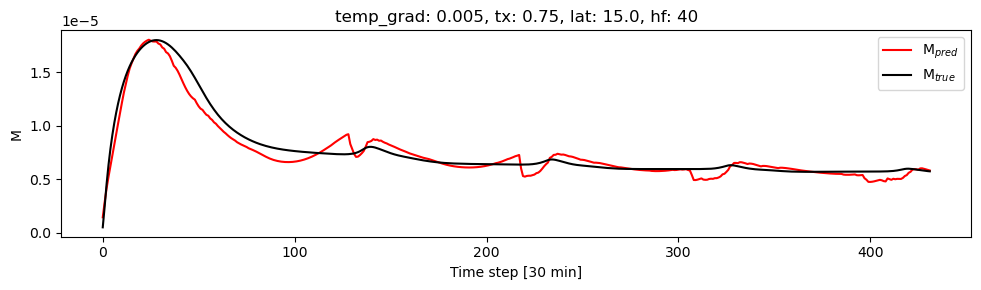

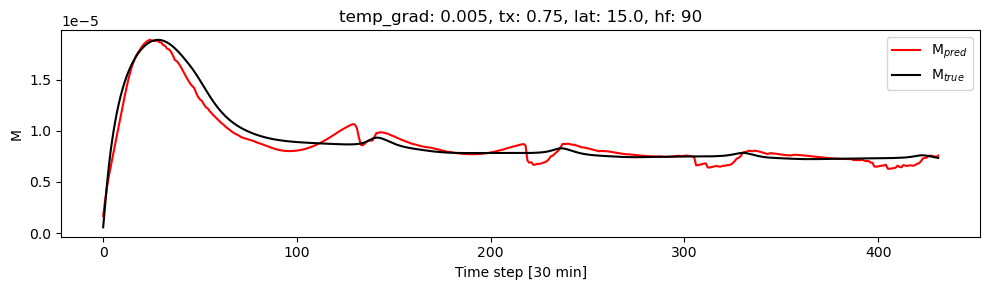

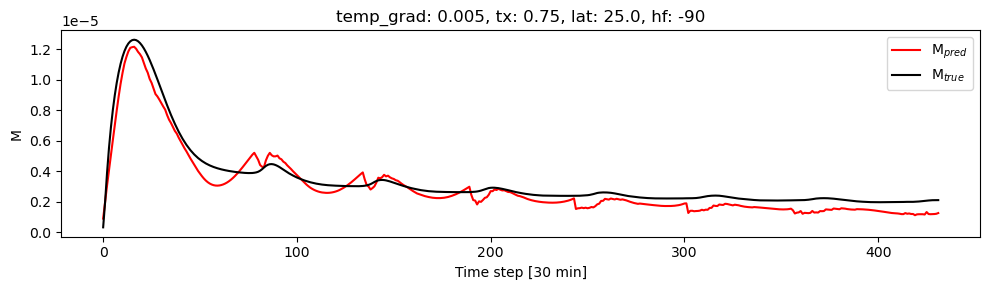

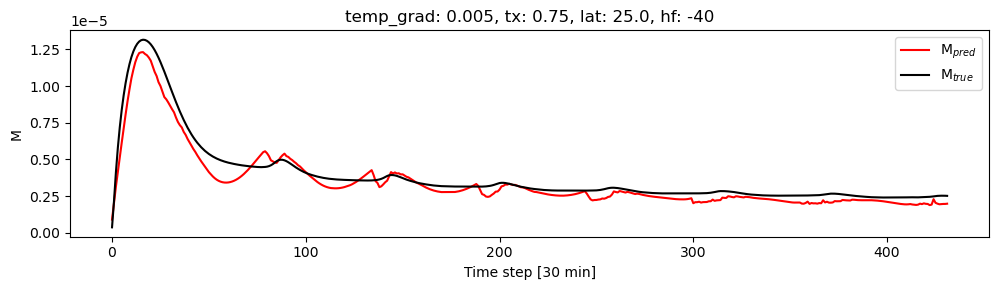

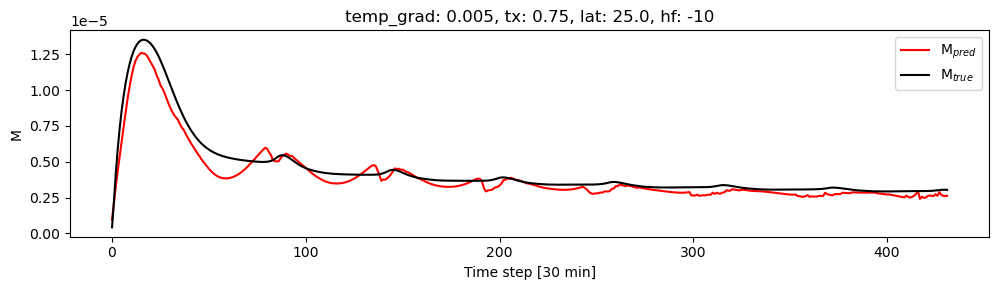

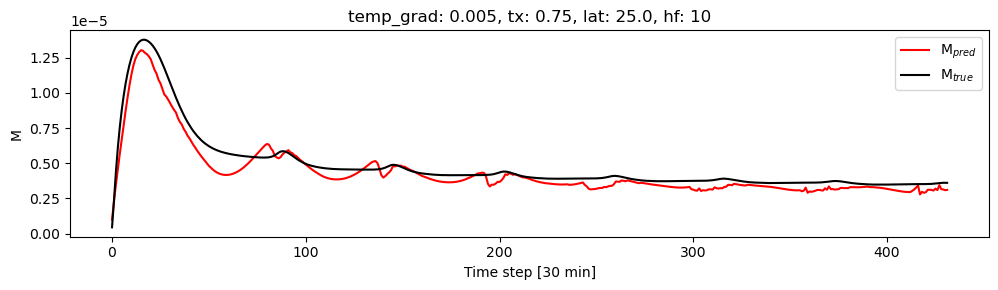

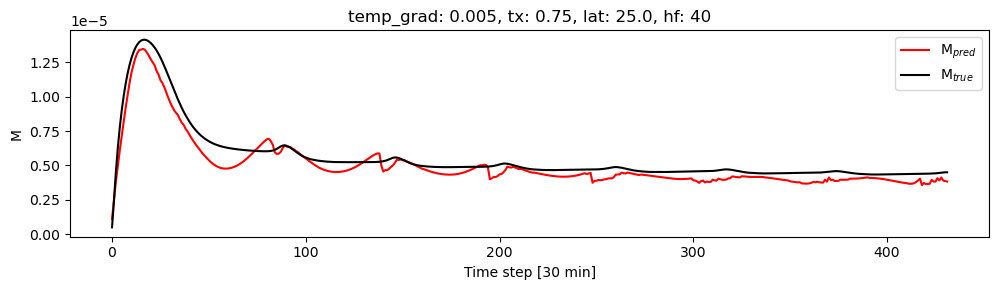

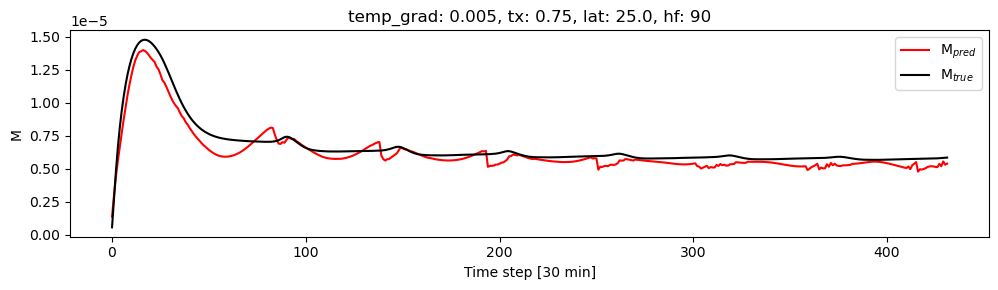

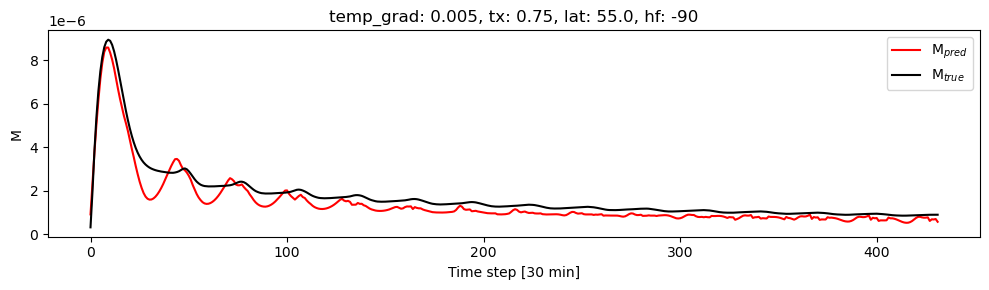

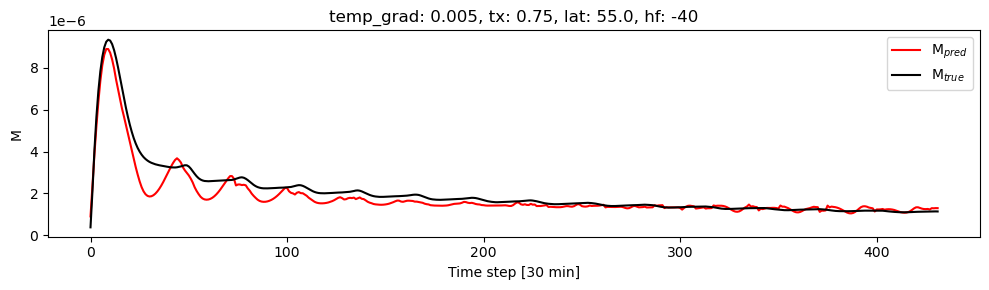

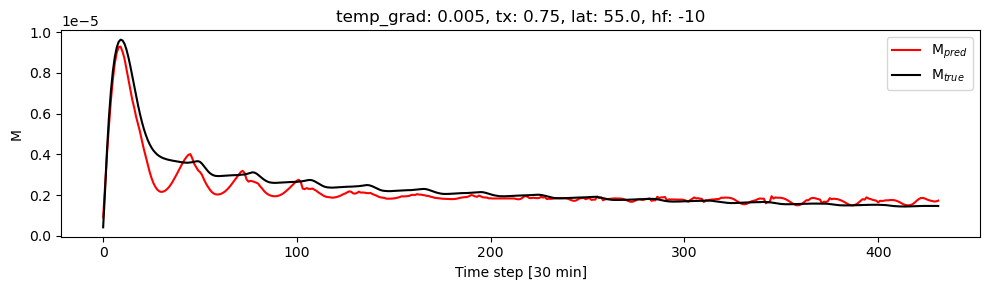

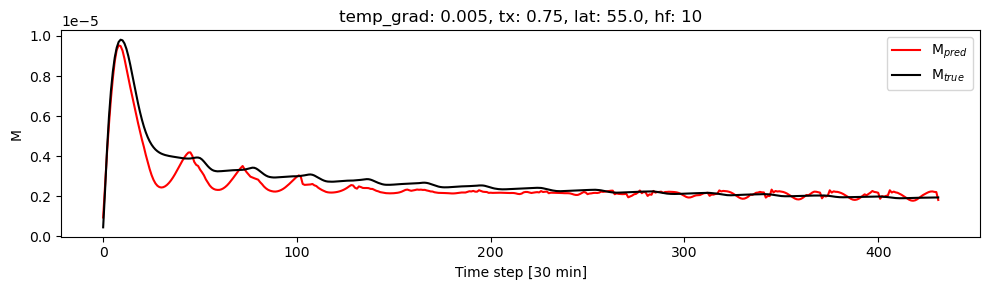

In [12]:
start, end = 0, 40
n_timesteps = 432

for i in range(start, end):
    case_specs = gotm_validation_case_dict[f"case_{i+1}"]
    tg, tx, lat, hf = case_specs['temp_grad'], case_specs['tx'], case_specs['lat'], case_specs['heat_flux']
    plt.figure(tight_layout=True, figsize=(10,3))
    plt.title(f"temp_grad: {tg}, tx: {tx}, lat: {lat}, hf: {hf}")
    plt.plot(fcnn_prediction_val.detach().numpy()[i], label="M$_{pred}$", color="red")
    plt.plot(y_val[i], label="M$_{true}$", color="black")
    plt.xlabel("Time step [30 min]")
    plt.ylabel("M")
    plt.legend()